In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("BitcoinSentimentAnalysis").getOrCreate()

Carimento dei dataset

In [ ]:
tweets_df = spark.read \
.option("header", True) \
.option("inferSchema", True) \
.option("multiLine", True) \
.option("quote", '"') \
.option("escape", '"') \
.csv("/content/drive/MyDrive/Colab_Notebooks/Big_Data/bitcoin_tweets.csv", header=True, inferSchema=True)
btc_df = spark.read.csv("/content/drive/MyDrive/Colab_Notebooks/Big_Data/BTC-USD.csv", header=True, inferSchema=True)

In [ ]:
tweets_df.printSchema()
tweets_df.head(5)

root
 |-- id: double (nullable = true)
 |-- user: string (nullable = true)
 |-- fullname: string (nullable = true)
 |-- url: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- replies: double (nullable = true)
 |-- likes: double (nullable = true)
 |-- retweets: double (nullable = true)
 |-- text: string (nullable = true)



[Row(id=1.1329770553003008e+18, user='KamdemAbdiel', fullname='Abdiel kamdem', url=None, timestamp=datetime.datetime(2019, 5, 27, 11, 49, 14), replies=0.0, likes=0.0, retweets=0.0, text='È appena uscito un nuovo video! LES CRYPTOMONNAIES QUI PULVÉRISENT BITCOIN EN 2019 https://t.co/yCsQMvRnyS'),
 Row(id=1.1329770734027366e+18, user='bitcointe', fullname='Bitcointe', url=None, timestamp=datetime.datetime(2019, 5, 27, 11, 49, 18), replies=0.0, likes=0.0, retweets=0.0, text='Cardano: Digitize Currencies; EOS https://t.co/1kTKqKEBlS 6500% ROI; AT&amp;T Bitcoin Bill Pay https://t.co/eQCwOXKHK0   |  Cardano (ADA) 🌏📢😎🤑💵 | #FolloForFolloBack #follo4folloback #followforfollow #bitcointe #cryptocurrency'),
 Row(id=1.1329770238931396e+18, user='3eyedbran', fullname='Bran - 3 Eyed Raven', url=None, timestamp=datetime.datetime(2019, 5, 27, 11, 49, 6), replies=0.0, likes=2.0, retweets=1.0, text="Another Test tweet that wasn't caught in the stream ! bitcoin"),
 Row(id=1.1329770890895564e+18, user='De

In [ ]:
btc_df.printSchema()
btc_df.head(5)

root
 |-- Date: timestamp (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: long (nullable = true)
 |-- Dividends: double (nullable = true)
 |-- Stock Splits: double (nullable = true)



[Row(Date=datetime.datetime(2014, 9, 17, 0, 0), Open=465.864013671875, High=468.17401123046875, Low=452.4219970703125, Close=457.3340148925781, Volume=21056800, Dividends=0.0, Stock Splits=0.0),
 Row(Date=datetime.datetime(2014, 9, 18, 0, 0), Open=456.8599853515625, High=456.8599853515625, Low=413.10400390625, Close=424.44000244140625, Volume=34483200, Dividends=0.0, Stock Splits=0.0),
 Row(Date=datetime.datetime(2014, 9, 19, 0, 0), Open=424.1029968261719, High=427.8349914550781, Low=384.5320129394531, Close=394.7959899902344, Volume=37919700, Dividends=0.0, Stock Splits=0.0),
 Row(Date=datetime.datetime(2014, 9, 20, 0, 0), Open=394.6730041503906, High=423.2959899902344, Low=389.88299560546875, Close=408.90399169921875, Volume=36863600, Dividends=0.0, Stock Splits=0.0),
 Row(Date=datetime.datetime(2014, 9, 21, 0, 0), Open=408.0849914550781, High=412.4259948730469, Low=393.1809997558594, Close=398.8210144042969, Volume=26580100, Dividends=0.0, Stock Splits=0.0)]

Data Cleaning sul testo dei tweet

In [ ]:
from pyspark.sql.functions import col, trim

tweet_df = tweets_df.filter(
    (col("text").isNotNull()) & (trim(col("text")) != "")
    )

Pulizia anche su timestamp

In [ ]:
tweets_df = tweets_df.filter(col("timestamp").rlike(r'^\d{4}-\d{2}-\d{2}'))

Conversione di timestamp

In [ ]:
from pyspark.sql.functions import to_timestamp

tweets_df = tweets_df.withColumn("timestamp_clean", to_timestamp(col("timestamp")))

In [ ]:
from pyspark.sql.functions import to_date

tweets_df = tweets_df.withColumn("date", to_date(col("timestamp_clean")))

In [ ]:
tweets_df = tweets_df.filter(col("date").isNotNull())

In [ ]:
tweets_df.printSchema()

root
 |-- id: double (nullable = true)
 |-- user: string (nullable = true)
 |-- fullname: string (nullable = true)
 |-- url: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- replies: double (nullable = true)
 |-- likes: double (nullable = true)
 |-- retweets: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp_clean: timestamp (nullable = true)
 |-- date: date (nullable = true)



In [ ]:
tweets_df.select("timestamp", "timestamp_clean","date").show(10, False)

+-------------------+-------------------+----------+
|timestamp          |timestamp_clean    |date      |
+-------------------+-------------------+----------+
|2019-05-27 11:49:14|2019-05-27 11:49:14|2019-05-27|
|2019-05-27 11:49:18|2019-05-27 11:49:18|2019-05-27|
|2019-05-27 11:49:06|2019-05-27 11:49:06|2019-05-27|
|2019-05-27 11:49:22|2019-05-27 11:49:22|2019-05-27|
|2019-05-27 11:49:23|2019-05-27 11:49:23|2019-05-27|
|2019-05-27 11:49:25|2019-05-27 11:49:25|2019-05-27|
|2019-05-27 11:49:25|2019-05-27 11:49:25|2019-05-27|
|2019-05-27 11:49:27|2019-05-27 11:49:27|2019-05-27|
|2019-05-27 11:49:32|2019-05-27 11:49:32|2019-05-27|
|2019-05-27 11:49:32|2019-05-27 11:49:32|2019-05-27|
+-------------------+-------------------+----------+
only showing top 10 rows


**Sentiment Analysis**

In [ ]:
import nltk
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

Creazione della funzione per sentiment, utilizzando vader, modello NLP specifico per social media

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType, FloatType

sia = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
  try:
    if not text: return 0.0
    return sia.polarity_scores(text)["compound"]
  except:
    return 0.0

sentiment_score_udf = udf(get_sentiment_score, FloatType())
tweets_df = tweets_df.withColumn("sentiment_score", sentiment_score_udf(col("text")))

In [ ]:
tweets_df.printSchema()

root
 |-- id: double (nullable = true)
 |-- user: string (nullable = true)
 |-- fullname: string (nullable = true)
 |-- url: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- replies: double (nullable = true)
 |-- likes: double (nullable = true)
 |-- retweets: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp_clean: timestamp (nullable = true)
 |-- date: date (nullable = true)
 |-- sentiment: string (nullable = true)
 |-- sentiment_score: float (nullable = true)



In [ ]:
tweets_df.select("text","sentiment","sentiment_score").show(5, False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+---------------+
|text                                                                                                                                                                                                                                                 |sentiment|sentiment_score|
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+---------------+
|È appena uscito un nuovo video! LES CRYPTOMONNAIES QUI PULVÉRISENT BITCOIN EN 2019 https://t.co/yCsQMvRnyS                                                                       

---

**Analisi temporale del sentiment**

Grafico temporale

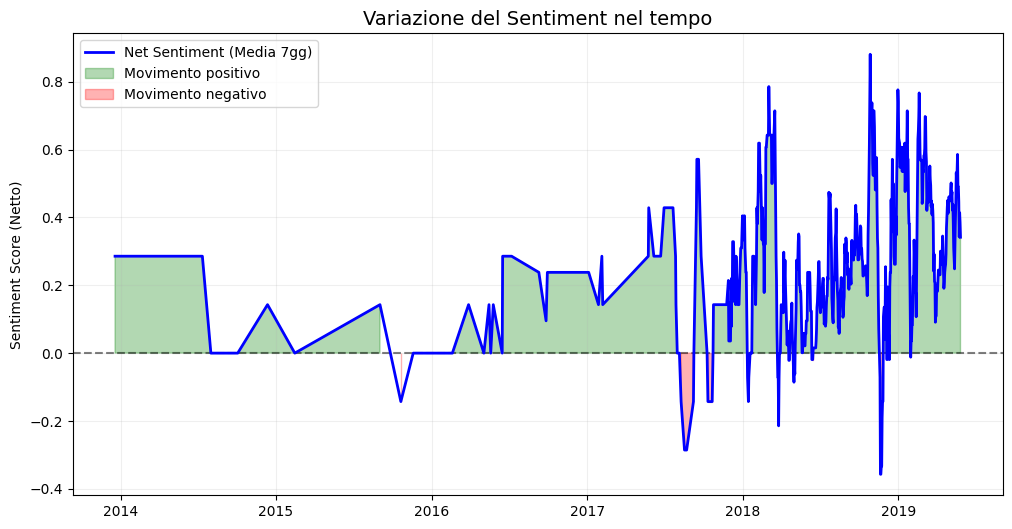

In [ ]:
import matplotlib.pyplot as plt

pdf_pivot = pdf.pivot(index="date", columns="sentiment", values="count").fillna(0)

#net sentiment
pdf_pivot['net_sentiment'] = (pdf_pivot['positive'] - pdf_pivot['negative']) / \
                             (pdf_pivot['positive'] + pdf_pivot['negative'] + pdf_pivot['neutral'])

#Media mobile a 7 giorni
pdf_pivot['net_smooth'] = pdf_pivot['net_sentiment'].rolling(window=7).mean()

plt.figure(figsize=(12, 6))

#Linea dello zero
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

#linea del sentiment netto
plt.plot(pdf_pivot.index, pdf_pivot['net_smooth'], color='blue', linewidth=2, label='Net Sentiment (Media 7gg)')

#aree colorate
plt.fill_between(pdf_pivot.index, pdf_pivot['net_smooth'], 0,
                 where=(pdf_pivot['net_smooth'] >= 0), color='green', alpha=0.3, label='Movimento positivo')
plt.fill_between(pdf_pivot.index, pdf_pivot['net_smooth'], 0,
                 where=(pdf_pivot['net_smooth'] < 0), color='red', alpha=0.3, label='Movimento negativo')

plt.title("Variazione del Sentiment nel tempo", fontsize=14)
plt.ylabel("Sentiment Score (Netto)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

---

**Analisi Engagement**

Domanda 1: i tweet negativi ricevono più likes?

In [ ]:
tweets_df.groupBy("sentiment") \
.avg("likes") \
.withColumnRenamed("avg(likes)", "avg_likes") \
.show()

+---------+------------------+
|sentiment|         avg_likes|
+---------+------------------+
| positive| 9.281810917137939|
|  neutral| 5.040292644249829|
| negative|11.631693258708546|
+---------+------------------+



Domanda 2: i tweet negativi ricevono più risposte?

In [ ]:
tweets_df.groupBy("sentiment") \
.avg("replies") \
.withColumnRenamed("avg(replies)", "avg_replies") \
.show()

+---------+-------------------+
|sentiment|        avg_replies|
+---------+-------------------+
| positive| 1.3711581017949348|
|  neutral|0.44583198183587414|
| negative| 1.1870353353938685|
+---------+-------------------+



In [ ]:
from pyspark.sql.functions import avg
engagement_analysis = tweets_df.groupBy("sentiment").agg(
    avg("likes").alias("media_likes"),
    avg("replies").alias("media_replies")
)
engagement_analysis.show()

+---------+------------------+-------------------+
|sentiment|       media_likes|      media_replies|
+---------+------------------+-------------------+
| positive| 9.281810917137939| 1.3711581017949348|
|  neutral| 5.040292644249829|0.44583198183587414|
| negative|11.631693258708546| 1.1870353353938685|
+---------+------------------+-------------------+



Grafico dell'engagement medio di like e risposte per sentiment

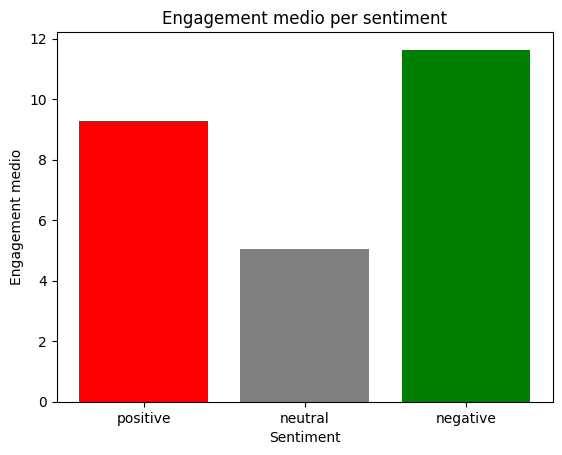

In [ ]:
pdf_engagement= engagement_analysis.toPandas()

plt.bar(pdf_engagement["sentiment"], pdf_engagement["media_likes"], color=["red", "gray", "green"])
plt.title("Engagement medio per sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Engagement medio")
plt.show()

Grazie al grafico, possiamo vedere meglio i dati delle medie sopra riportate e notare a colpo d'occhio che i tweet con sentiment negativo ricevono mediamente più like; riguardo invece alle risposte, i tweet con sentiment positivo sono leggermente più alti di quelli con sentitment negativo.

---

**Relazione tra variazione del sentiment e variazione del valore del Bitcoin**

Pulizia dataset BTC

In [ ]:
btc_df = btc_df.withColumn("Date", to_date(col("Date")))
btc_df = btc_df.select("Date", "Close")

Preparazione sentiment

In [ ]:
#punteggio medio giornaliero
daily_sentiment_score = tweets_df.groupBy("date").agg(avg(col("sentiment_score")).alias("avg_sentiment"))

btc_df_clean = btc_df.withColumnRenamed("Date", "date")

#unione dati
merged_df = daily_sentiment_score.join(btc_df_clean, ["date"])

Calcolo variazioni

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import lag

windowSpec = Window.orderBy("date")

merged_df = merged_df.withColumn("prev_price", lag("Close", 1).over(windowSpec)) \
                     .withColumn("price_change", (col("Close") - col("prev_price")) / col("prev_price")) \
                     .withColumn("prev_sentiment", lag("avg_sentiment", 1).over(windowSpec)) \
                     .withColumn("sentiment_change", col("avg_sentiment") - col("prev_sentiment"))


Rimozione dei null generati dal lag

In [ ]:
merged_final = merged_df.dropna()

Calcolo correlazione di Pearson

In [ ]:
correlation = merged_final.stat.corr("sentiment_change", "price_change")
print("Correlazione tra variazione sentiment e variazione prezzo:", correlation)

Correlazione tra variazione sentiment e variazione prezzo: 0.05507535253302032


In [ ]:
merged_final.select("date", "avg_sentiment", "Close", "price_change", "sentiment_change").show(5)

+----------+--------------------+------------------+--------------------+-------------------+
|      date|       avg_sentiment|             Close|        price_change|   sentiment_change|
+----------+--------------------+------------------+--------------------+-------------------+
|2014-12-12|  0.3612000048160553|    352.5419921875|-0.01938739554869072| 0.8016000092029572|
|2015-02-14|                 0.0| 257.3210144042969|-0.27009825749370503|-0.3612000048160553|
|2015-09-02|  0.7900999784469604|229.28399658203125|-0.10895735774698333| 0.7900999784469604|
|2015-10-21|-0.29600000381469727| 266.2720031738281|  0.1613196173443515|-1.0860999822616577|
|2015-11-19| 0.22630000114440918|326.14898681640625| 0.22487149579705956| 0.5223000049591064|
+----------+--------------------+------------------+--------------------+-------------------+
only showing top 5 rows


Con il dato ottenuto dal calcolo della correlazione (0.05507535253302032) possiamo ritenere che non esista una correlazione significativa tra la variazione del sentiment e la variazione del prezzo del Bitcoin.

Nonostante la correlazione globale sia bassa, non possiamo escludere che il sentiment possa influenzare il prezzo durante eventi estremi (come dei crolli improvvisi), in particolare il sentiment negativo che crea paura e fa così muovere gli investitori.

---

Grafico del confronto

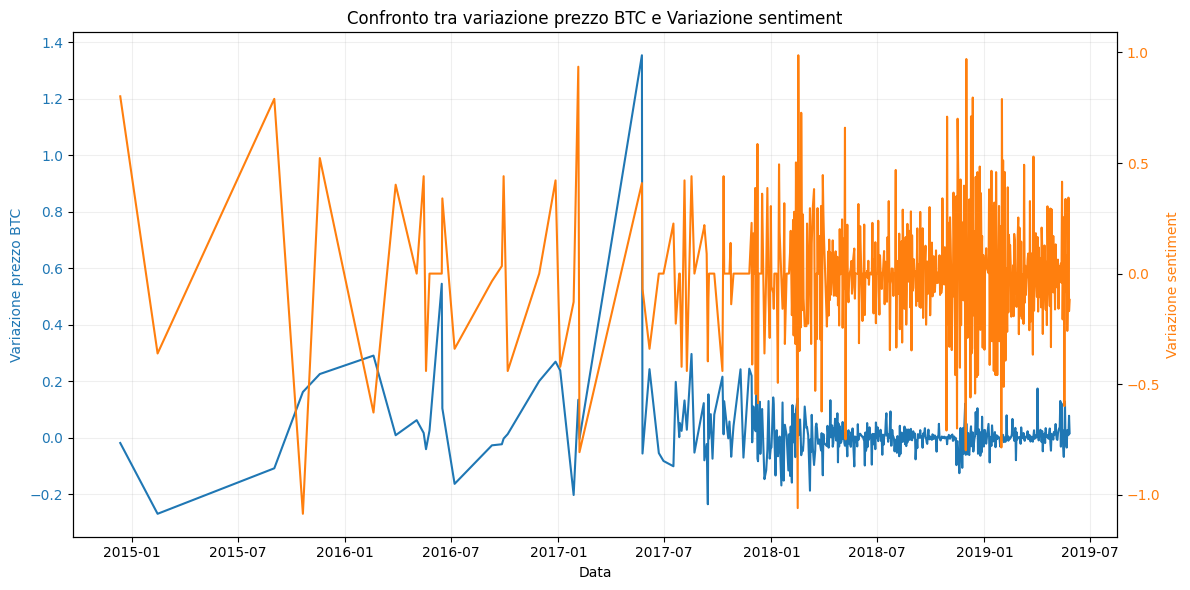

In [ ]:
pdf2 = merged_final.orderBy("date").toPandas()

#grafico a due assi
fig, ax1 = plt.subplots(figsize=(12, 6))

#asse 1
color_price="tab:blue"
ax1.set_xlabel("Data")
ax1.set_ylabel("Variazione prezzo BTC", color=color_price)
ax1.plot(pdf2["date"], pdf2["price_change"], color=color_price, label="variazione")
ax1.tick_params(axis="y", labelcolor=color_price)

#asse 2
ax2 = ax1.twinx()
color_sentiment="tab:orange"
ax2.set_ylabel("Variazione sentiment", color=color_sentiment)
ax2.plot(pdf2["date"], pdf2["sentiment_change"], color=color_sentiment, label="variazione")
ax2.tick_params(axis="y", labelcolor=color_sentiment)

plt.title("Confronto tra variazione prezzo BTC e Variazione sentiment", fontsize=12)
ax1.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()